In [13]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
matchup_data = pd.read_csv("matchup_features.csv")

matchup_data.head()

,gameId,season_year,home_win,home_team,home_last_5_win_pct,home_offensive_average,home_defensive_average,home_last_5_point_diff,away_season_year,away_home_win,away_team,away_last_5_win_pct,away_offensive_average,away_defensive_average,away_last_5_point_diff,win_pct_diff,offense_diff,defense_diff,point_diff_diff
0,22000083,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,2021,0,Cleveland Cavaliers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22000095,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,2021,0,New York Knicks,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,22000110,2021,0,Atlanta Hawks,NaN,NaN,NaN,NaN,2021,0,Charlotte Hornets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,22000153,2021,1,Atlanta Hawks,0.2,102.4,104.0,-1.6,2021,1,Philadelphia 76ers,0.6,119.6,117.2,2.4,-0.4,-17.2,-13.2,-4.0
4,22000205,2021,1,Atlanta Hawks,0.2,101.8,107.4,-5.6,2021,1,Minnesota Timberwolves,0.2,111.6,117.8,-6.2,0.0,-9.8,-10.4,0.6


In [23]:
feature_cols = [
    "win_pct_diff",
    "offense_diff",
    "defense_diff",
    "point_diff_diff"
]

model_df = matchup_data[
    feature_cols + ["home_win", "season_year"]
].dropna()
model_df.head()

,win_pct_diff,offense_diff,defense_diff,point_diff_diff,home_win,season_year
3,-0.4,-17.2,-13.2,-4.0,1,2021
4,0.0,-9.8,-10.4,0.6,1,2021
5,0.0,-0.2,1.6,-1.8,1,2021
6,-0.4,-8.4,10.6,-19.0,1,2021
7,0.2,-5.8,-13.2,7.4,0,2021


creating X and Y

In [25]:
X = matchup_data[feature_cols]

y = matchup_data["home_win"] # our target variable

In [26]:
train_df = model_df[model_df["season_year"] <= 2024].copy()
test_df = model_df[model_df["season_year"] == 2025].copy()

X_train = train_df[feature_cols]
y_train = train_df["home_win"]

X_test = test_df[feature_cols]
y_test = test_df["home_win"]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5736, 4)
Testing shape: (1387, 4)


5736 rows and 4 columns. in training data from 2021-2024. 1387 rows and 4 columns in test data from 2024-2025.

Now we will be trying different models.

Logistic regression

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

preds = log_model.predict(X_test)

probs = log_model.predict_proba(X_test)[:, 1]

In [28]:
accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy)

print("Classification Report:")
print(classification_report(y_test, preds))

Accuracy: 0.6337418889689979
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.45      0.53       630
           1       0.63      0.79      0.70       757

    accuracy                           0.63      1387
   macro avg       0.63      0.62      0.61      1387
weighted avg       0.63      0.63      0.62      1387



model correctly predicted 63.5% of the outcomes in the test set.so 878 games are good.  When the model predicts an away team win it is correct 64% of time and 63% of home wins.  This model captures only 0.45 the wins by an away team. so the model favors the home team predictions. so the home team with strong recent forms usually win. 

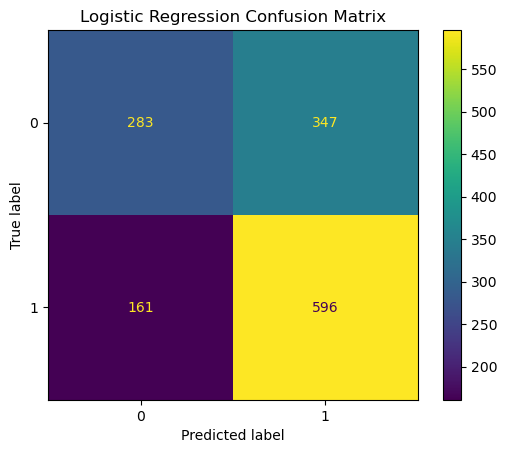

In [29]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.show()

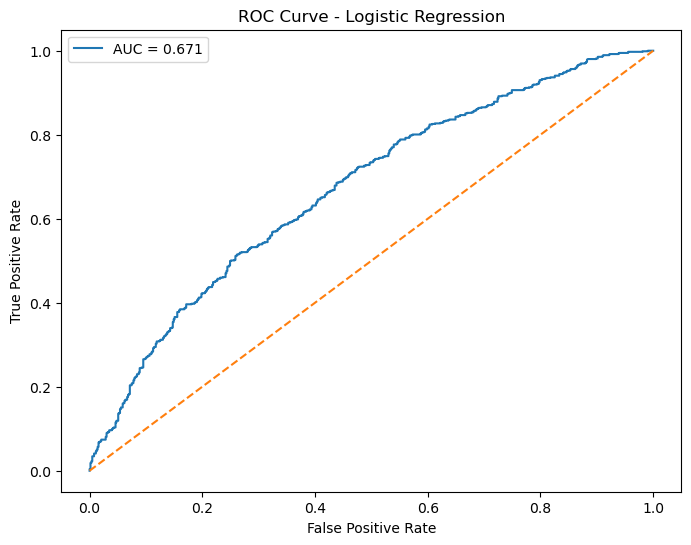

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, probs)

auc_score = roc_auc_score(y_test, probs)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

Orange dashed line is random guessing and the blue lineis my model. AUC= 0.671 means meaningful predictive skills.